# Overnight vs Intraday Returns: Nifty 50

A trading day splits into two parts. The market is open from 9:15am to 3:30pm,
and shut for the other seventeen and a half hours. News does not stop overnight —
US markets trade, companies announce results, governments act — so prices gap
when the market reopens.

This notebook splits 15 years of Nifty 50 returns into those two components and
asks which one produced the market's gains. The effect is documented in US
equities, where intraday returns are roughly flat. This tests whether it holds
in Indian data.

Definitions, for each day t:
- **overnight** = open(t) / close(t−1) − 1
- **intraday** = close(t) / open(t) − 1
- **total** = close(t) / close(t−1) − 1

The first two compose exactly into the third, since the open price cancels.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sps

## Data

Nifty 50 daily prices from Yahoo Finance via yfinance, from January 2010 to
21 August 2026. The download returns a two-level column header, which we flatten.
Volume is reported as zero throughout — Yahoo does not publish volume for the
index itself, so no volume-based analysis is possible here.

In [2]:
df = yf.download("^NSEI", start="2010-01-01", end="2026-08-21")
df.columns = df.columns.droplevel(1)

print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(4085, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0
2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0
2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0
2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0
2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0


## Decomposition and sanity check

`shift(1)` gives the previous day's value. Since the two components multiply to
the total by construction, we verify it: the maximum discrepancy across all days
should be at the level of floating-point rounding, around 1e-15. Anything larger
would mean the decomposition is wrong.

In [3]:
df["overnight"] = df["Open"] / df["Close"].shift(1) - 1
df["intraday"]  = df["Close"] / df["Open"] - 1
df["total"]     = df["Close"] / df["Close"].shift(1) - 1

check = (1 + df["overnight"]) * (1 + df["intraday"]) - 1
print("Max decomposition error:", (check - df["total"]).abs().max())

Max decomposition error: 2.220446049250313e-16


## Headline result

Growth of ₹1 under three strategies: held only overnight (buy at every close,
sell at every open), held only intraday (buy at every open, sell at every close),
and held throughout.

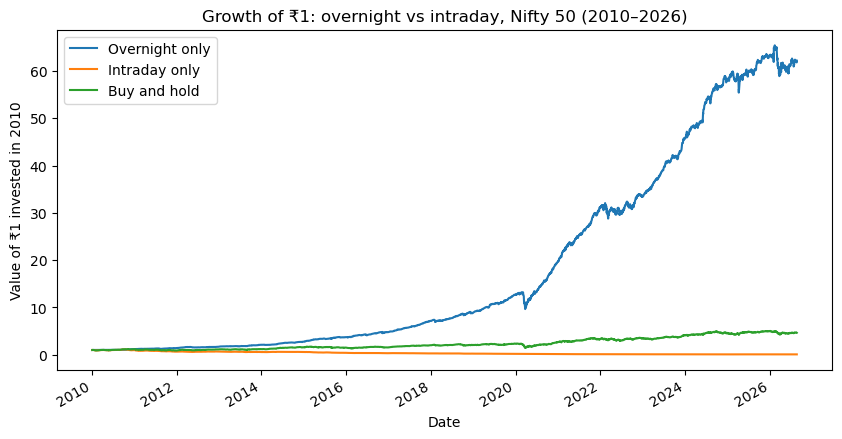

Price
overnight    62.17
intraday      0.07
total         4.63
Name: 2026-08-20 00:00:00, dtype: float64


In [4]:
cumulative = (1 + df[["overnight", "intraday", "total"]].fillna(0)).cumprod()

ax = cumulative.plot(figsize=(10, 5))
ax.set_title("Growth of ₹1: overnight vs intraday, Nifty 50 (2010–2026)")
ax.set_ylabel("Value of ₹1 invested in 2010")
ax.set_xlabel("Date")
ax.legend(["Overnight only", "Intraday only", "Buy and hold"])
plt.show()

print(cumulative.iloc[-1].round(2))

₹1 held overnight-only grew to ₹62.17. Held intraday-only it fell to ₹0.07, a
loss of almost everything. Buy-and-hold returned ₹4.63.

So the entire equity premium, and more, accrued while the market was closed. The
trading day, where all the volume and news coverage sits, subtracted value on net.
Note that the three multiply (overnight × intraday = total), which is the daily
identity compounded over the whole sample.

A result this large should invite suspicion before excitement. The whole finding
sits in the Open column, which is the least reliable field in free data, so the
next three cells check it.

## Check 1: stale opens

If Yahoo has no real opening print for a day, it may copy the previous close.
That would force the overnight return to zero and push the entire day's move into
the intraday component — manufacturing our result out of nothing. We count how
often the open exactly equals the previous close, and how often the overnight
move is smaller than a basis point.

In [5]:
stale = (df["Open"] == df["Close"].shift(1))
print("Exactly stale opens:", stale.sum(), "out of", len(df))

near_stale = (df["overnight"].abs() < 0.0001)
print("Near-zero overnight moves:", near_stale.sum())

Exactly stale opens: 12 out of 4085
Near-zero overnight moves: 161


12 exactly stale opens out of 4,085 (0.3%), and 161 near-zero moves (4%, which is
just quiet nights). Too few to explain anything.

## Check 2: extreme days

If the largest overnight moves were data glitches rather than real events, the
result would be an artefact. We list the ten biggest gains and losses and check
them against what actually happened.

In [6]:
print("10 biggest overnight gains:")
print((df["overnight"].nlargest(10) * 100).round(2))

print("\n10 biggest overnight losses:")
print((df["overnight"].nsmallest(10) * 100).round(2))

10 biggest overnight gains:
Date
2026-02-03    4.86
2020-04-07    4.48
2020-05-13    4.22
2020-04-17    3.68
2024-06-03    3.58
2020-03-27    3.56
2026-04-08    3.16
2020-03-24    3.13
2020-03-31    3.00
2011-10-28    2.90
Name: overnight, dtype: float64

10 biggest overnight losses:
Date
2020-03-23   -9.14
2016-11-09   -5.57
2020-03-13   -5.03
2025-04-07   -5.00
2020-03-19   -4.79
2020-03-12   -4.00
2020-03-16   -3.69
2020-06-12   -3.61
2018-02-06   -3.48
2011-08-09   -3.33
Name: overnight, dtype: float64


Every extreme day corresponds to a documented event. The worst night was
2020-03-23 (−9.1%), the Covid crash, and six of the ten worst fall in March 2020.
2016-11-09 (−5.6%) was the US election result and India's demonetisation
announcement landing overnight together; 2018-02-06 was the global volatility
selloff; 2011-08-09 followed the US credit downgrade; 2025-04-07 was the tariff
shock. The largest gains are Covid rebound days and 2024-06-03, the morning after
the election exit polls.

No unexplained values in twenty observations.

## Check 3: do a few extreme nights drive the result?

We cap the most extreme 1% of overnight returns at the 1st and 99th percentiles
(capping rather than deleting, so the series stays continuous) and recompute the
cumulative line. If the premium lives in a handful of lucky gaps, clipping should
collapse it.

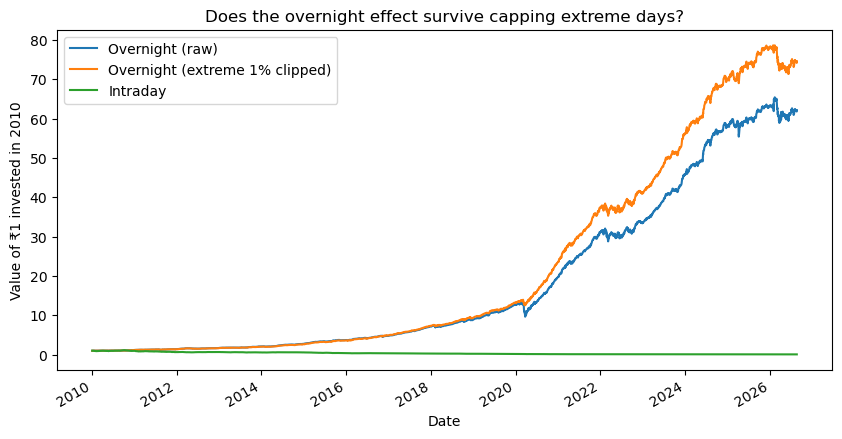

In [7]:
lo, hi = df["overnight"].quantile([0.01, 0.99])
clipped = df["overnight"].clip(lo, hi)

ax = (1 + df["overnight"].fillna(0)).cumprod().plot(
    figsize=(10, 5), label="Overnight (raw)")
(1 + clipped.fillna(0)).cumprod().plot(
    ax=ax, label="Overnight (extreme 1% clipped)")
(1 + df["intraday"].fillna(0)).cumprod().plot(
    ax=ax, label="Intraday")

ax.set_title("Does the overnight effect survive capping extreme days?")
ax.set_ylabel("Value of ₹1 invested in 2010")
ax.set_xlabel("Date")
ax.legend()
plt.show()

The clipped line ends *higher* than the raw one. Capping the extremes made the
overnight investor richer, which means extreme nights were net negative overall.

So the premium is not a few large gaps. It is a small, steady accrual across
thousands of ordinary nights, earned despite the extreme nights rather than
because of them.

## Statistics

Daily means and volatilities, annualised by multiplying the mean by 252 and the
volatility by √252 (means add; variances add, so volatility scales with the root).
Sharpe uses a flat 6.5% risk-free rate — an assumption, not a T-bill series.

The t-tests ask whether each mean is distinguishable from zero given how noisy
daily returns are.

In [8]:
cols = ["overnight", "intraday", "total"]
rf = 0.065   # flat assumption for India's risk-free rate

stats = pd.DataFrame({
    "mean (bps/day)": df[cols].mean() * 1e4,
    "vol (bps/day)":  df[cols].std() * 1e4,
    "ann. return %":  df[cols].mean() * 252 * 100,
    "ann. vol %":     df[cols].std() * np.sqrt(252) * 100,
})
stats["Sharpe"] = (stats["ann. return %"] - rf * 100) / stats["ann. vol %"]
print(stats.round(2))

for c in ["overnight", "intraday"]:
    t, p = sps.ttest_1samp(df[c].dropna(), 0)
    print(f"\n{c} vs 0: t = {t:.2f}, p = {p:.4f}")

           mean (bps/day)  vol (bps/day)  ann. return %  ann. vol %  Sharpe
Price                                                                      
overnight           10.30          60.78          25.96        9.65    2.02
intraday            -5.96          86.74         -15.03       13.77   -1.56
total                4.29         103.73          10.82       16.47    0.26

overnight vs 0: t = 10.83, p = 0.0000

intraday vs 0: t = -4.40, p = 0.0000


Overnight earns 10.30 bps a night (26.0% annualised); intraday loses 5.96 bps a
night (−15.0% annualised). Both t-statistics are far beyond conventional
significance, at 10.8 and −4.4 against a usual threshold of about 2, so luck
doesn't explain either result.

Two things worth noting. Intraday carries *more* risk than overnight (86.7 vs
60.8 bps daily volatility) for a negative return. And buy-and-hold has a Sharpe
of 0.26, which is unremarkable. All of the risk-adjusted quality in this index
sits in the overnight component.

The t-tests assume returns are independent and identically distributed. The
rolling volatility chart below shows that assumption is imperfect.

## Sub-periods

If the effect came from one unusual era it would be a historical curiosity rather
than a feature of the market. We split the sample into three roughly equal
five-year blocks.

In [9]:
periods = {
    "2010–2015": ("2010-01-01", "2015-12-31"),
    "2016–2020": ("2016-01-01", "2020-12-31"),
    "2021–2026": ("2021-01-01", "2026-12-31"),
}

rows = []
for label, (start, end) in periods.items():
    sub = df.loc[start:end]
    rows.append({
        "period": label,
        "overnight ann. %": sub["overnight"].mean() * 252 * 100,
        "intraday ann. %":  sub["intraday"].mean() * 252 * 100,
        "n days": len(sub),
    })

print(pd.DataFrame(rows).round(1).to_string(index=False))

   period  overnight ann. %  intraday ann. %  n days
2010–2015              23.0            -14.2    1465
2016–2020              34.9            -21.5    1228
2021–2026              21.2            -10.2    1392


Overnight is positive and intraday negative in all three windows. The magnitude
varies — 2016–2020 is the strongest, which is also the most turbulent window —
but the signs never flip.

The most recent period is the mildest (+21.2%), which raises the question of
whether the effect is fading. Three data points cannot answer that, and the
figure is close to 2010–2015's +23.0%, so there is no clear trend either way.

## Volatility regimes

For each day we compute the standard deviation of total returns over the previous
21 trading days — a trailing gauge of how turbulent the market has been. Because
the window looks backwards, the label uses only information available at the time.

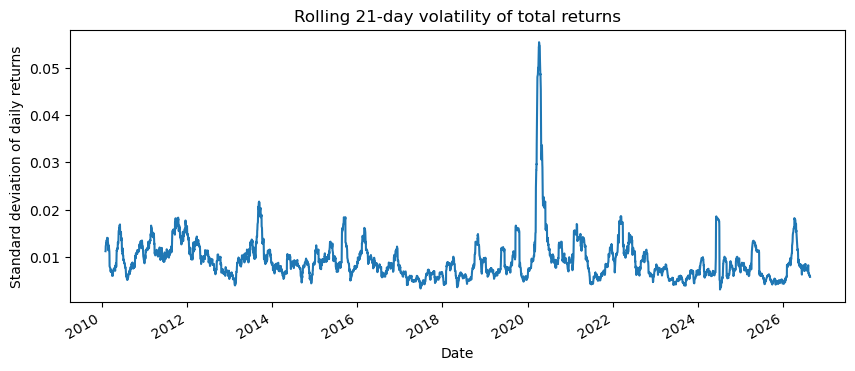

In [10]:
df["roll_vol"] = df["total"].rolling(21).std()

ax = df["roll_vol"].plot(figsize=(10, 4))
ax.set_title("Rolling 21-day volatility of total returns")
ax.set_ylabel("Standard deviation of daily returns")
ax.set_xlabel("Date")
plt.show()

Volatility is clearly not constant. It spikes to 0.055 in March 2020, roughly ten
times its usual level, with smaller peaks in 2011, 2013, 2015, 2018, 2022 and
2026 — and each spike persists for weeks rather than days.

Because the states persist, the i.i.d. assumption behind the t-test and
annualisation doesn't strictly hold.

We label the top quartile of this series as high volatility and compare the two
groups.

In [11]:
threshold = df["roll_vol"].quantile(0.75)
df["regime"] = np.where(df["roll_vol"] > threshold, "high vol", "calm")

regime_stats = df.groupby("regime")[["overnight", "intraday"]].mean() * 252 * 100
regime_stats["n days"] = df.groupby("regime").size()
print(regime_stats.round(1))

Price     overnight  intraday  n days
regime                               
calm           23.3     -14.6    3069
high vol       33.9     -16.2    1016


The overnight premium is *larger* in turbulent periods: 33.9% annualised against
23.3% in calm ones, while intraday stays negative in both.

This is the opposite of what we expected, given that crashes arrive as overnight
gaps. The reconciliation is that a high-volatility period is mostly ordinary
nights — only a handful are extreme. The rare crashes do drag on returns, but
ordinary nights within turbulent stretches pay a larger premium than ordinary
nights in calm ones, and that dominates.

That is what a risk premium should look like: payment rises when the risk is
visibly greater.

One caveat: the 75th percentile cutoff is a choice, not something the data
dictated, and the results have not been re-run at other thresholds.

## Case study: 2020

The fastest crash and recovery in the sample, examined day by day.

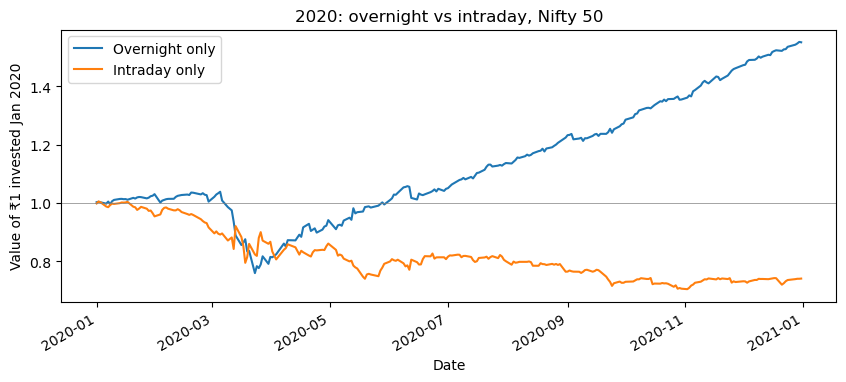

Price
overnight    1.551
intraday     0.741
total        1.149
Name: 2020-12-31 00:00:00, dtype: float64


In [12]:
sub = df.loc["2020-01-01":"2020-12-31"]
cum_2020 = (1 + sub[["overnight", "intraday", "total"]].fillna(0)).cumprod()

ax = cum_2020[["overnight", "intraday"]].plot(figsize=(10, 4))
ax.axhline(1, color="grey", lw=0.5)
ax.set_title("2020: overnight vs intraday, Nifty 50")
ax.set_ylabel("Value of ₹1 invested Jan 2020")
ax.set_xlabel("Date")
ax.legend(["Overnight only", "Intraday only"])
plt.show()

print(cum_2020.iloc[-1].round(3))

Both components fall together through March. The Covid panic hit around the
clock, gapping the opens down on global news and selling through Indian sessions.

From April the two separate completely. The overnight line climbs from 0.76 to
1.55 by December; the intraday line bottoms near 0.74 and stays there. The
recovery everyone watched was built entirely between 3:30pm and 9:15am, because
the news driving it (Fed stimulus, US market rallies, vaccine announcements)
broke while India slept. By the open, prices had already gapped up to reflect it,
leaving nothing for the trading session to add.

Year-end: overnight 1.55, intraday 0.74, total 1.15.

The intraday line is not a price. It is a running total of session returns, and
the Nifty itself recovered its level. Nothing was pulling sessions systematically
positive, so the intraday component never earned back what it lost, in 2020 as in
every other year.

## Transaction costs: could anyone trade this?

Capturing the overnight premium requires two transactions every trading day. The
question is whether the edge survives that. We price a real round trip and work
downwards.

Nifty futures are the cheapest liquid way to get index exposure, so this is the
best case: if costs kill the strategy here, they kill it anywhere. Priced on
Zerodha's brokerage calculator, 20 August 2026, one lot of 65 units at 24,297.60
(a notional of ₹15,79,344): total charges ₹941.14, of which ₹790 is STT.

In [13]:
edge_bps = 10.29          # mean overnight return, from the stats table
charges  = 941.14         # Zerodha, one Nifty futures round trip
notional = 24297.60 * 65  # one leg

cost_bps = charges / notional * 1e4
net_bps  = edge_bps - cost_bps

print(f"Round-trip cost: {cost_bps:.2f} bps")
print(f"Net edge: {net_bps:.2f} bps/night -> {net_bps * 252 / 100:.1f}% annualised")
print(f"Break-even cost: {edge_bps:.2f} bps\n")

for c in [2, 4, 6, 8, 10]:
    net = edge_bps - c
    print(f"cost {c:>2} bps -> net {net:>5.1f} bps/night -> {net * 252 / 100:>6.1f}% annualised")

Round-trip cost: 5.96 bps
Net edge: 4.33 bps/night -> 10.9% annualised
Break-even cost: 10.29 bps

cost  2 bps -> net   8.3 bps/night ->   20.9% annualised
cost  4 bps -> net   6.3 bps/night ->   15.9% annualised
cost  6 bps -> net   4.3 bps/night ->   10.8% annualised
cost  8 bps -> net   2.3 bps/night ->    5.8% annualised
cost 10 bps -> net   0.3 bps/night ->    0.7% annualised


The sensitivity table brackets the estimate: the strategy breaks even at around
10 bps of cost, so its viability lives inside a window of a few basis points.

The overnight trade earns 10.3 bps per night, or roughly 26% annualised gross. A
round trip costs about 6.0 bps, based on Zerodha's brokerage calculator for one
Nifty futures lot — most of it STT. That leaves a net edge of 4.3 bps per night,
or about 11% annualised, which would be further reduced by slippage and the
bid-ask spread. At 11%, the strategy sits only ~4.5% above India's risk-free
rate. It is worth questioning whether that extra 4.5% warrants the risk of
holding overnight through crashes like Covid-19. So why doesn't everyone trade
overnight and earn 26%? From that 4.5%, an unknown amount is subtracted due to
slippage and spread, and the rest can be thought of as compensation for the risk
taken by holding it through potential overnight crashes.

## Limitations

Data. `^NSEI` is a price index. It records the price drop when a stock goes
ex-dividend but not the dividend that offsets it; since Indian stocks go
ex-dividend at the open, that drop falls in the overnight return, so the overnight
figure is slightly understated. No volume data is available for the index ticker.

Statistical assumptions. The t-tests, the annualisation and the √252 scaling
all assume returns are independent and identically distributed. The rolling
volatility chart shows sustained high and low states, so they are not identically
distributed, and volatility clustering means adjacent days are not fully
independent either. The Sharpe ratio treats volatility as the measure of risk,
which is only adequate for symmetric returns — the worst night was −9.1% against
a best of +4.9%, and clipping the extremes raised returns, so the tails skew
negative and volatility understates the real danger.

Design. The 75th percentile volatility cutoff, the five-year sub-period
blocks and the 1%/99% clipping thresholds were all judgement calls. The results
have not been re-run under alternative specifications.

Implementation. The analysis assumes transactions at the official opening and
closing auction prices, which cannot reliably be achieved. Costs are priced on
futures while returns are measured on the spot index, and futures returns differ
because of the basis and the need to roll monthly. Today's cost structure is
applied across the whole sample; the historical structure differed and was
plausibly higher, which we have not quantified. Slippage, spread, rolling and
idle margin are named but unmeasured. The three strategies are accounting
constructs rather than portfolios anyone could run.

Scope. One index, one fifteen-year sample.

## Conclusion

Over 2010–2026, the Nifty 50's entire equity premium accrued outside trading
hours. Overnight returns averaged 26.0% annualised against −15.0% intraday, and
the result survives checks for stale data, extreme days, sub-period variation and
volatility regimes.

It is not an exploitable anomaly. Explicit costs of about 6.0 bps per round trip
take the 10.3 bps nightly edge down to roughly 11% annualised, only about 4.5%
above the risk-free rate, before slippage and other frictions. What remains is
best read as compensation for holding through overnight crashes — which is
plausibly why the premium persists rather than being arbitraged away.